In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("fishing_fleet.csv")
df
#inspecting the dataset

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,eng_pow,Engine power,gear,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,GT,Gross tonnage (GT),KW1000-1999,From 1 000 to 1 999 kW,DRE,...,BE,Belgium,2013,NaN,385,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,GT,Gross tonnage (GT),KW1000-1999,From 1 000 to 1 999 kW,DRE,...,BE,Belgium,2014,NaN,385,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,GT,Gross tonnage (GT),KW1000-1999,From 1 000 to 1 999 kW,DRE,...,BE,Belgium,2015,NaN,385,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,GT,Gross tonnage (GT),KW1000-1999,From 1 000 to 1 999 kW,DRE,...,BE,Belgium,2016,NaN,385,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,GT,Gross tonnage (GT),KW1000-1999,From 1 000 to 1 999 kW,DRE,...,BE,Belgium,2017,NaN,385,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97214,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,NR,Number,UNK,Unknown,TRW,...,IT,Italy,1997,NaN,12,NaN,NaN,NaN,NaN,NaN
97215,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,NR,Number,UNK,Unknown,TRW,...,IT,Italy,1998,NaN,8,NaN,NaN,NaN,NaN,NaN
97216,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,NR,Number,UNK,Unknown,TRW,...,IT,Italy,1999,NaN,7,NaN,NaN,NaN,NaN,NaN
97217,dataflow,ESTAT:FISH_FLEET_GP(1.0),Fishing fleet by type of gear and engine power,A,Annual,NR,Number,UNK,Unknown,TRW,...,IT,Italy,2000,NaN,4,NaN,NaN,NaN,NaN,NaN


## Preprocessing

In [2]:

df.drop(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency','Time','Observation value', 'OBS_FLAG','gear','Engine power','Observation status (Flag) V2 structure','CONF_STATUS', 'Confidentiality status (flag)'], axis=1, inplace = True)
df = df.rename(columns={
    "Geopolitical entity (reporting)": "geo_entity",
    "Fishing gears": "gear",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "value"
})


In [3]:
print(df.tail())

      unit Unit of measure eng_pow    gear geo geo_entity  year  value
97214   NR          Number     UNK  Trawls  IT      Italy  1997     12
97215   NR          Number     UNK  Trawls  IT      Italy  1998      8
97216   NR          Number     UNK  Trawls  IT      Italy  1999      7
97217   NR          Number     UNK  Trawls  IT      Italy  2000      4
97218   NR          Number     UNK  Trawls  IT      Italy  2001      4


In [4]:
df.info()
print(df['gear'].apply(type).value_counts())

# check for null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97219 entries, 0 to 97218
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   unit             97219 non-null  object
 1   Unit of measure  97219 non-null  object
 2   eng_pow          97219 non-null  object
 3   gear             97219 non-null  object
 4   geo              97219 non-null  object
 5   geo_entity       97219 non-null  object
 6   year             97219 non-null  int64 
 7   value            97219 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 5.9+ MB
gear
<class 'str'>    97219
Name: count, dtype: int64


In [5]:
df_year99 = df[df['year'] == 1999]
x = df_year99.groupby('gear')['value'].sum()
print(x)
df_year2020 = df[df['year'] == 2020]
y = df_year2020.groupby('gear')['value'].sum()
print(y)
#df.plot(x = 'geo', )

gear
Dredges                           1434375
Gear unknown                       764449
Gill nets and entangling nets     5852148
Hooks and lines                   4461298
Lift nets                            1317
Seines                             273842
Surrounding nets                  4156145
Total                            39431296
Traps                             1775910
Trawls                           20711810
Name: value, dtype: int64
gear
Dredges                           1177584
Gear unknown                          234
Gill nets and entangling nets     5636730
Hooks and lines                   3597010
Lift nets                           20141
Miscellaneous gear                  44683
No gear                              3358
Seines                             280955
Surrounding nets                  3398433
Total                            29484792
Traps                             1556478
Trawls                           11370111
Name: value, dtype: int64


In [22]:
df["year"].dtype
df["year"].head()

0    2013
1    2014
2    2015
3    2016
4    2017
Name: year, dtype: int64

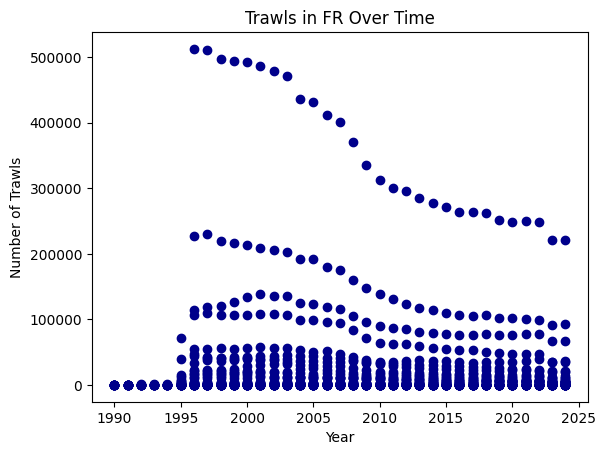

In [6]:
# Filter for one country and trawls
country = "FR"
gear = "Trawls"

dff = df.copy()

df_country = dff[
    (dff["geo"] == country) &
    (dff["gear"] == gear)
]

# Sort by year to ensure proper time ordering
df_country = df_country.sort_values("year")
plt.figure()
plt.scatter(df_country["year"], df_country["value"], color = 'darkblue')
plt.xlabel("Year")
plt.ylabel("Number of Trawls")
plt.title(f"Trawls in {country} Over Time")
plt.show()

(35, 8)


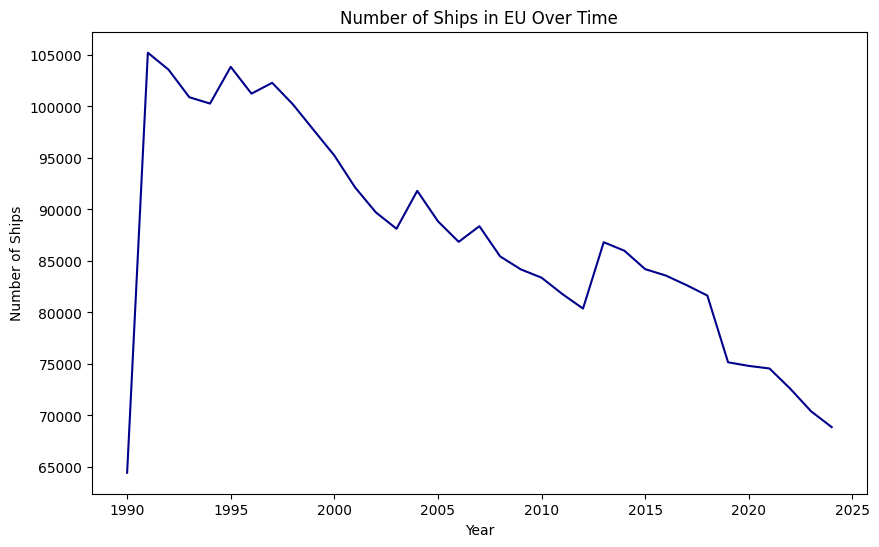

In [7]:
df_1 = df[
    (df["geo"] == "EU") & #instance EU
    (df["gear"] == "Total") & #all gears
    (df["unit"] == "NR") & #Displays Number
    (df["eng_pow"] == "TOTAL") #For all engine powers
]

df_1 = df_1.sort_values("year")
print(df_1.shape)
# Plot
plt.figure(figsize=(10,6))
plt.plot(df_1["year"], df_1["value"], color='darkblue')
plt.xlabel("Year")
plt.ylabel("Number of Ships")
plt.title("Number of Ships in EU Over Time")
plt.grid(False)
plt.show()

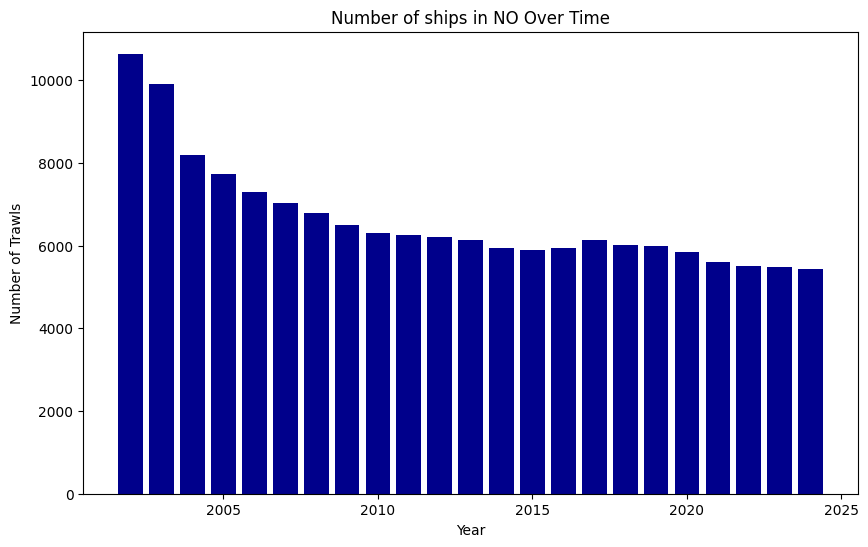

In [8]:
df_NO = df[
    (df["geo"] == "NO") &
    (df["gear"] == "Total") &
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL")
]
#print(df_country.head())
# Sort by year
df_NO = df_NO.sort_values("year")

# Plot
plt.figure(figsize=(10,6))
plt.bar(df_NO["year"], df_NO["value"], color='darkblue')
plt.xlabel("Year")
plt.ylabel("Number of Trawls")
plt.title("Number of ships in NO Over Time")
plt.grid(False)
plt.show()

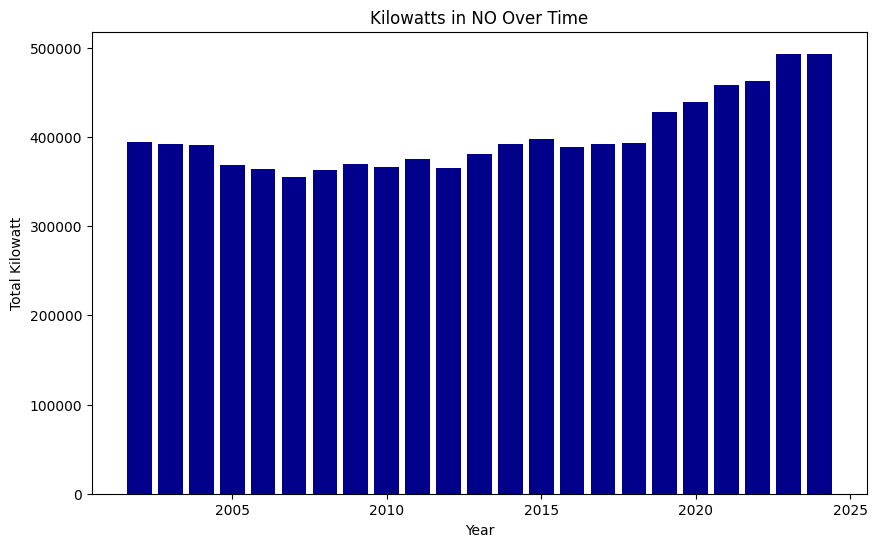

In [9]:
df_NO = df[
    (df["geo"] == "NO") &
    (df["gear"] == "Total") &
    (df["unit"] == "GT") &
    (df["eng_pow"] == "TOTAL")
]
#print(df_country.head())
# Sort by year
df_NO = df_NO.sort_values("year")

# Plot
plt.figure(figsize=(10,6))
plt.bar(df_NO["year"], df_NO["value"], color='darkblue')
plt.xlabel("Year")
plt.ylabel("Total Kilowatt")
plt.title("Kilowatts in NO Over Time")
plt.grid(False)
plt.show()

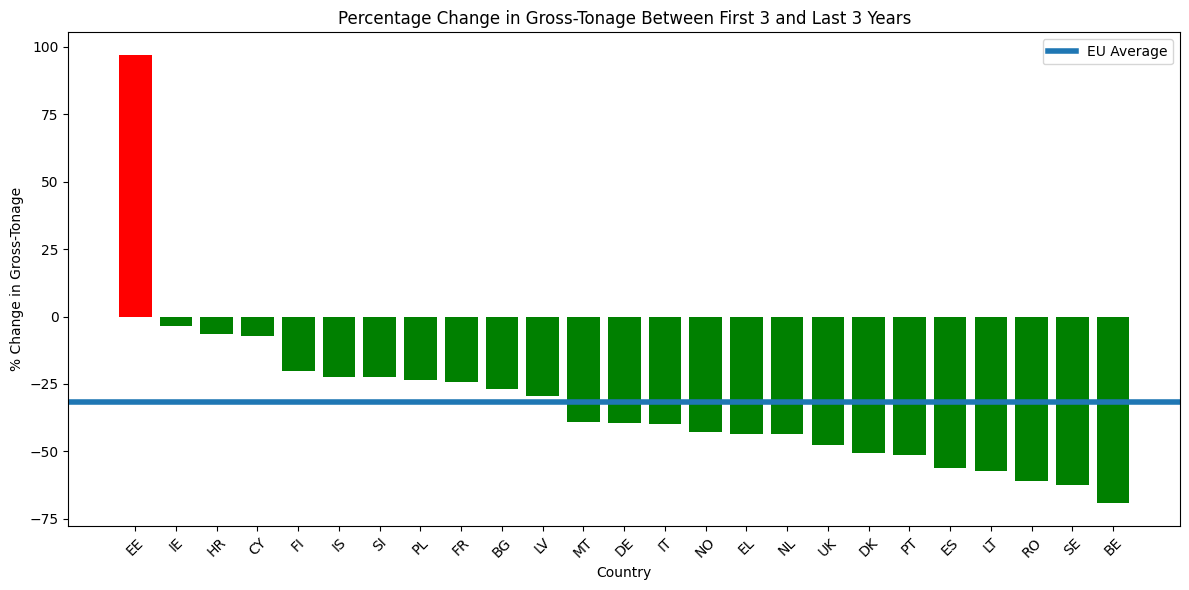

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter
df_filtered = df[
    (df["gear"] == "Total") &
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL")
]

# Percent change per country
percentage_changes = []
for country in df_filtered["geo"].unique():
    df_country = df_filtered[df_filtered["geo"] == country].sort_values("year")
    if len(df_country) >= 6:
        first_3 = df_country["value"].iloc[:3].mean()
        last_3 = df_country["value"].iloc[-3:].mean()
        pct_change = ((last_3 - first_3) / first_3) * 100
        percentage_changes.append({"Country": country, "Percent Change": pct_change})

df_changes = pd.DataFrame(percentage_changes)

# Remove EU row from bar plot
df_no_eu = df_changes[df_changes["Country"] != "EU"].copy()
df_no_eu = df_no_eu.sort_values("Percent Change", ascending=False)
avg_value = df_no_eu["Percent Change"].mean()

# Color logic (EU removed, so only pos/neg)
colors = ["red" if p > 0 else "green" for p in df_no_eu["Percent Change"]]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(df_no_eu["Country"], df_no_eu["Percent Change"], color=colors)
plt.axhline(y=avg_value, linewidth=4, linestyle="-", label="EU Average")
plt.ylabel("% Change in Gross-Tonage")
plt.xlabel("Country")
plt.title("Percentage Change in Gross-Tonage Between First 3 and Last 3 Years")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import cartopy.io.shapereader as shpreader

shp_path = shpreader.natural_earth(
    resolution='110m',
    category='cultural',
    name='admin_0_countries'
)

import geopandas as gpd
world = gpd.read_file(shp_path)


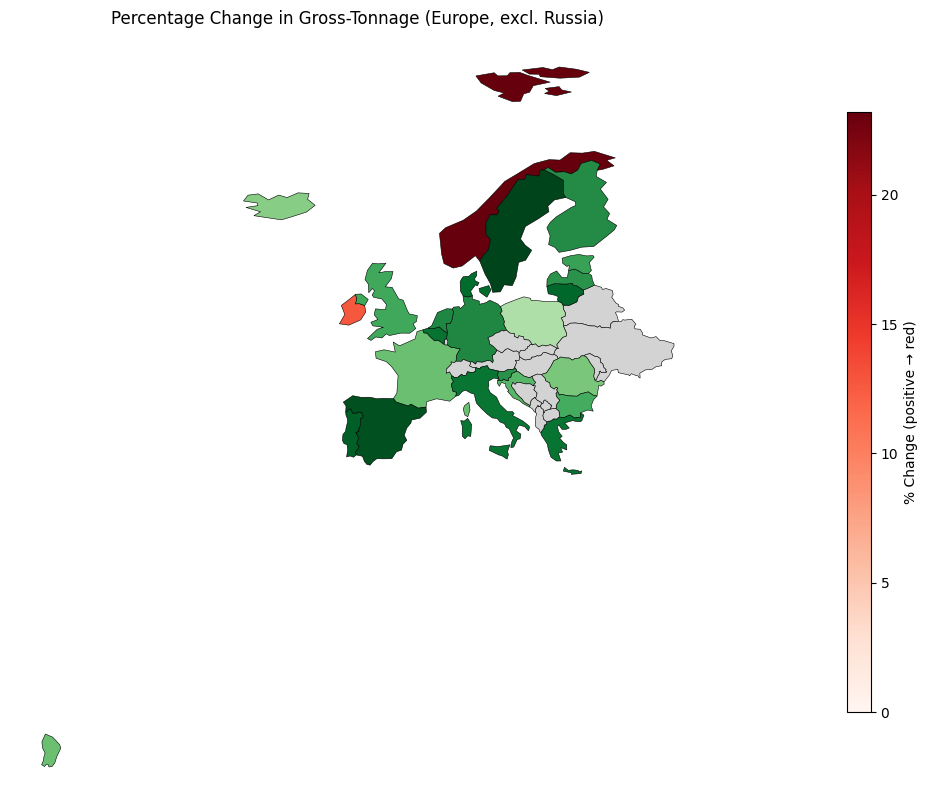

In [12]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np

# --- Map ISO2 to full names ---
iso2_to_name = {
    'BE': 'Belgium', 'BG': 'Bulgaria', 'CY': 'Cyprus', 'DE': 'Germany',
    'DK': 'Denmark', 'EE': 'Estonia', 'EL': 'Greece', 'ES': 'Spain',
    'FI': 'Finland', 'FR': 'France', 'HR': 'Croatia', 'IE': 'Ireland',
    'IS': 'Iceland', 'IT': 'Italy', 'LT': 'Lithuania', 'LV': 'Latvia',
    'MT': 'Malta', 'NL': 'Netherlands', 'NO': 'Norway', 'PL': 'Poland',
    'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden', 'SI': 'Slovenia',
    'UK': 'United Kingdom'
}

df_no_eu['Country_Name'] = df_no_eu['Country'].map(iso2_to_name)

# --- Load world shapes ---
path = shpreader.natural_earth(
    resolution='110m',
    category='cultural',
    name='admin_0_countries'
)
world = gpd.read_file(path)

# Filter Europe, exclude Russia
europe = world[(world["CONTINENT"] == "Europe") & (world["NAME"] != "Russia")].copy()

# Merge with data
europe = europe.merge(df_no_eu, how="left", left_on="NAME", right_on="Country_Name")

# --- Custom colormap ---
# negative values: green, positive values: red
def custom_cmap(value):
    if np.isnan(value):
        return "#d3d3d3"  # light gray for missing
    elif value < 0:
        # negative → darker green for bigger absolute values
        return plt.cm.Greens(np.interp(-value, [0, abs(europe['Percent Change'].min())], [0.3, 1]))
    else:
        # positive → darker red for bigger values
        return plt.cm.Reds(np.interp(value, [0, europe['Percent Change'].max()], [0.3, 1]))

europe['color'] = europe['Percent Change'].apply(custom_cmap)

# Plot
fig, ax = plt.subplots(figsize=(12,10))
europe.plot(ax=ax, color=europe['color'], edgecolor='black', linewidth=0.4)

ax.set_title("Percentage Change in Gross-Tonnage (Europe, excl. Russia)")
ax.axis('off')

# Build a colorbar manually
import matplotlib as mpl

# Prepare colormaps
neg_cmap = plt.cm.Greens
pos_cmap = plt.cm.Reds
min_neg = europe['Percent Change'][europe['Percent Change']<0].min() if any(europe['Percent Change']<0) else 0
max_pos = europe['Percent Change'][europe['Percent Change']>0].max() if any(europe['Percent Change']>0) else 0

# Create a combined colorbar with two segments
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])

# Negative values
if min_neg < 0:
    norm_neg = mpl.colors.Normalize(vmin=min_neg, vmax=0)
    sm_neg = mpl.cm.ScalarMappable(cmap=neg_cmap, norm=norm_neg)
    sm_neg.set_array([])
    cbar_neg = fig.colorbar(sm_neg, cax=cbar_ax, orientation='vertical', fraction=0.5, pad=0.0)
    cbar_neg.set_label('% Change (negative → green)', rotation=90)

# Positive values
if max_pos > 0:
    norm_pos = mpl.colors.Normalize(vmin=0, vmax=max_pos)
    sm_pos = mpl.cm.ScalarMappable(cmap=pos_cmap, norm=norm_pos)
    sm_pos.set_array([])
    cbar_pos = fig.colorbar(sm_pos, cax=cbar_ax, orientation='vertical', fraction=0.5, pad=0.0)
    cbar_pos.set_label('% Change (positive → red)', rotation=90)

plt.show()


      unit Unit of measure eng_pow   gear geo geo_entity  year  value
95168   NR          Number   TOTAL  Total  CY     Cyprus  2020    806
95169   NR          Number   TOTAL  Total  CY     Cyprus  2021    808
95170   NR          Number   TOTAL  Total  CY     Cyprus  2022    814
95171   NR          Number   TOTAL  Total  CY     Cyprus  2023    818
95172   NR          Number   TOTAL  Total  CY     Cyprus  2024    821


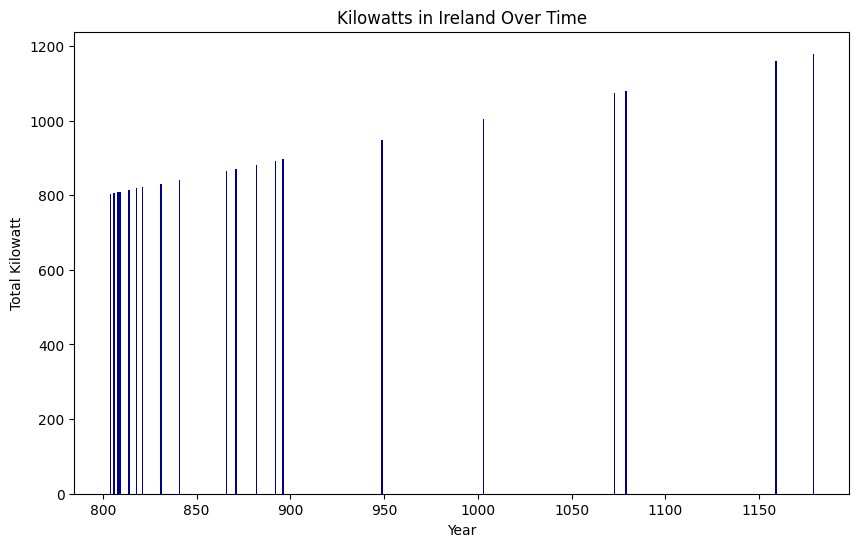

In [13]:
## Inspect NO and IE
df_IE = df[
    (df["geo"] == "CY") &
    (df["gear"] == "Total") &
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL")
]
print(df_IE.tail())
#print(df_country.head())
# Sort by year
df_IE = df_IE.sort_values("year")

# Plot
plt.figure(figsize=(10,6))
plt.bar(df_IE["value"], df_IE["value"], color='darkblue')
plt.xlabel("Year")
plt.ylabel("Total Kilowatt")
plt.title("Kilowatts in Ireland Over Time")
plt.grid(False)
plt.show()

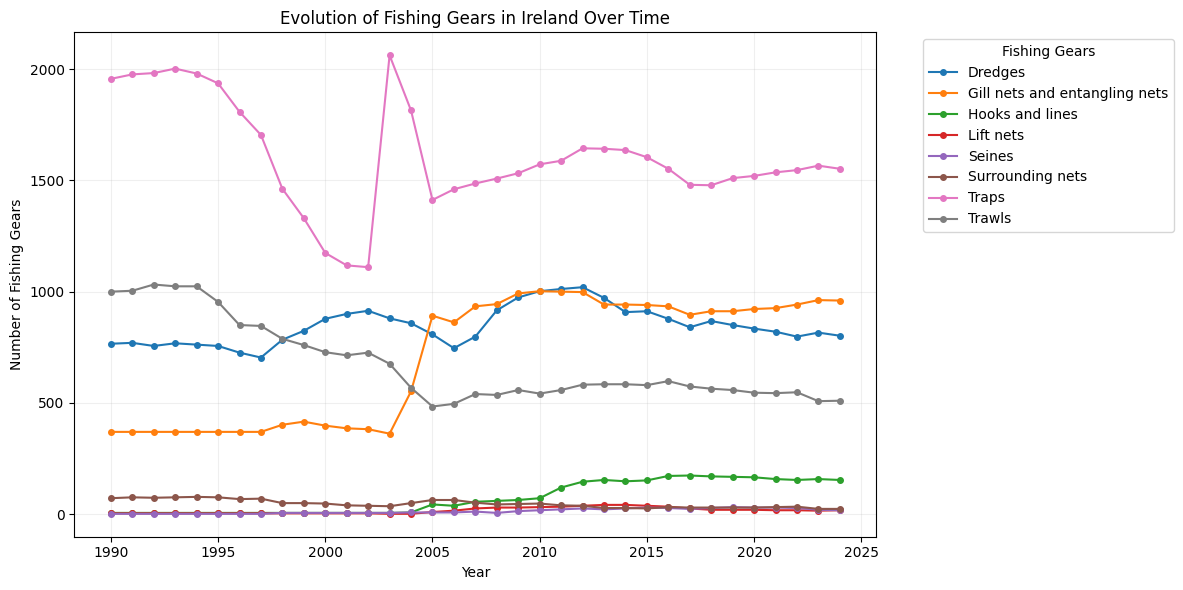

In [14]:
df_IE_gears = df[
    (df["geo"] == "IE") &
    (df["unit"] == "NR") &
    (df["gear"] != "Total")
]

# year as index, gear as columns and values
df_pivot = df_IE_gears.pivot_table(
    index="year",
    columns="gear",
    values="value",
    aggfunc="sum"
).fillna(0)

# LinePlot
plt.figure(figsize=(12,6))
for gear in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[gear], marker='o',markersize = 4, label=gear)

plt.xlabel("Year")
plt.ylabel("Number of Fishing Gears")
plt.title("Evolution of Fishing Gears in Ireland Over Time")
plt.legend(title="Fishing Gears", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha = 0.2)
plt.tight_layout()
plt.show()


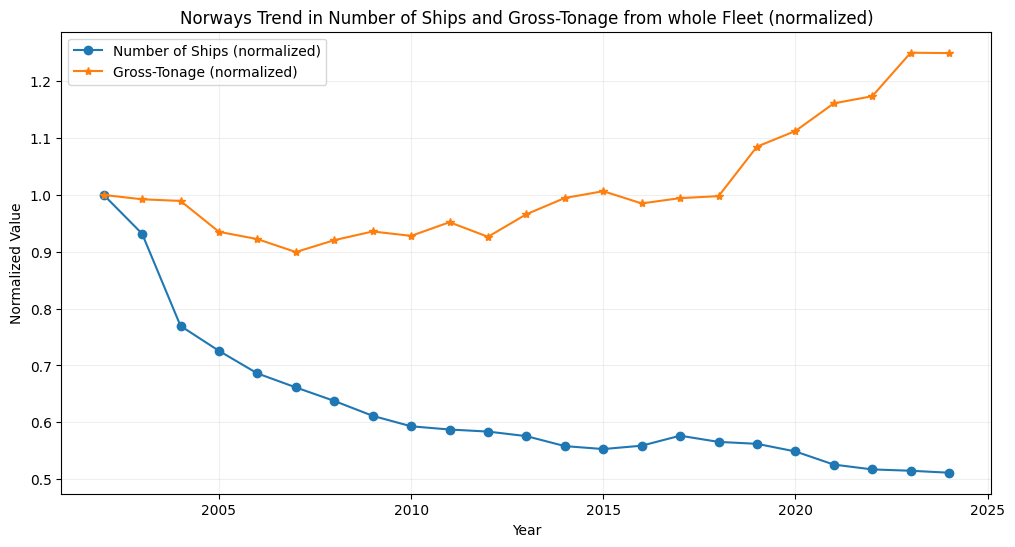

In [15]:
import matplotlib.pyplot as plt

# Filter für Irland, Gesamtfanggeräte, ohne Total
df_IE_num = df[
    (df["geo"] == "NO") &
    (df["gear"] == "Total") &
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL")
].sort_values("year")

df_IE_kw = df[
    (df["geo"] == "NO") &
    (df["gear"] == "Total") &
    (df["unit"] == "GT") &
    (df["eng_pow"] == "TOTAL")
].sort_values("year")

df_num_norm = df_IE_num["value"] / df_IE_num["value"].iloc[0]
df_kw_norm = df_IE_kw["value"] / df_IE_kw["value"].iloc[0]

plt.figure(figsize=(12,6))
plt.plot(df_IE_num["year"], df_num_norm, label="Number of Ships (normalized)", marker='o')
plt.plot(df_IE_kw["year"], df_kw_norm, label="Gross-Tonage (normalized)", marker='*')
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.title("Norways Trend in Number of Ships and Gross-Tonage from whole Fleet (normalized)")
plt.legend()
plt.grid(True, alpha = 0.2)
plt.show()

#

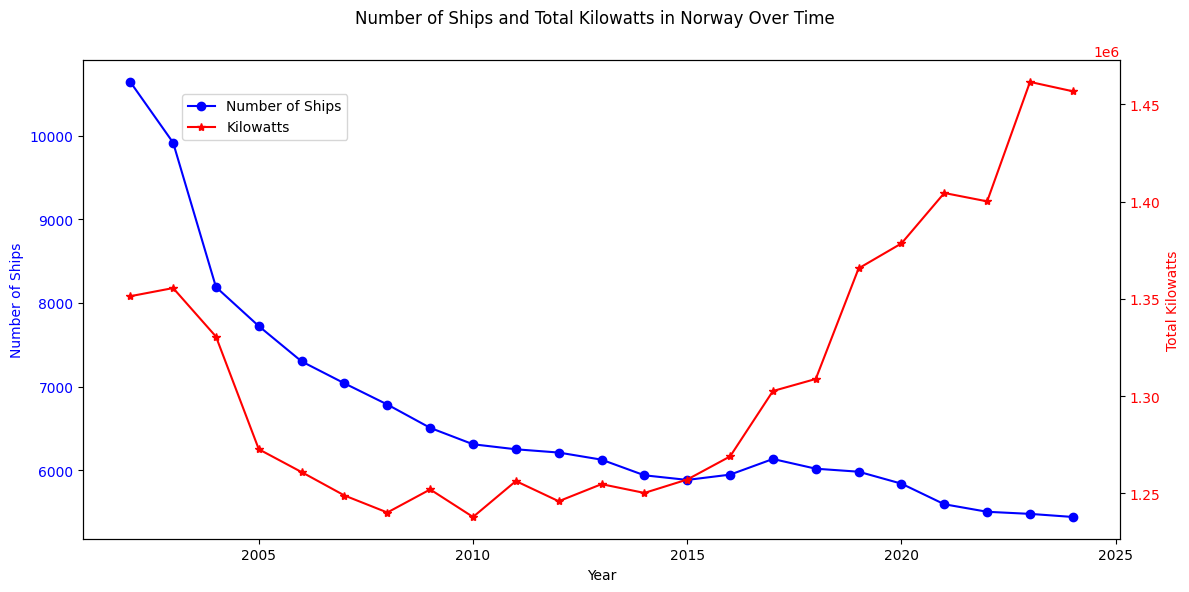

In [16]:
import matplotlib.pyplot as plt

# Filter für Irland, Gesamtfanggeräte, ohne Total
df_IE_num = df[
    (df["geo"] == "NO") &
    (df["gear"] == "Total") &
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL")
].sort_values("year")

df_IE_kw = df[
    (df["geo"] == "NO") &
    (df["gear"] == "Total") &
    (df["unit"] == "KW") &
    (df["eng_pow"] == "TOTAL")
].sort_values("year")
#
# Plot
fig, ax1 = plt.subplots(figsize=(12,6))

# Linie für Anzahl der Schiffe
ax1.plot(df_IE_num["year"], df_IE_num["value"], color='blue', marker='o', label="Number of Ships")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Ships", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Zweite Achse für Kilowatt
ax2 = ax1.twinx()
ax2.plot(df_IE_kw["year"], df_IE_kw["value"], color='red', marker='*', label="Kilowatts")
ax2.set_ylabel("Total Kilowatts", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titel und Legende
fig.suptitle("Number of Ships and Total Kilowatts in Norway Over Time")
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.15,0.85))
plt.show()

#

### Data Quality Analysis


In [17]:
df_norway = df[
    #(df["gear"] == "R") &
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL")&
    (df["geo"] == "IS")

]
df_norway
df_norway['gear'].unique()


array(['Total'], dtype=object)

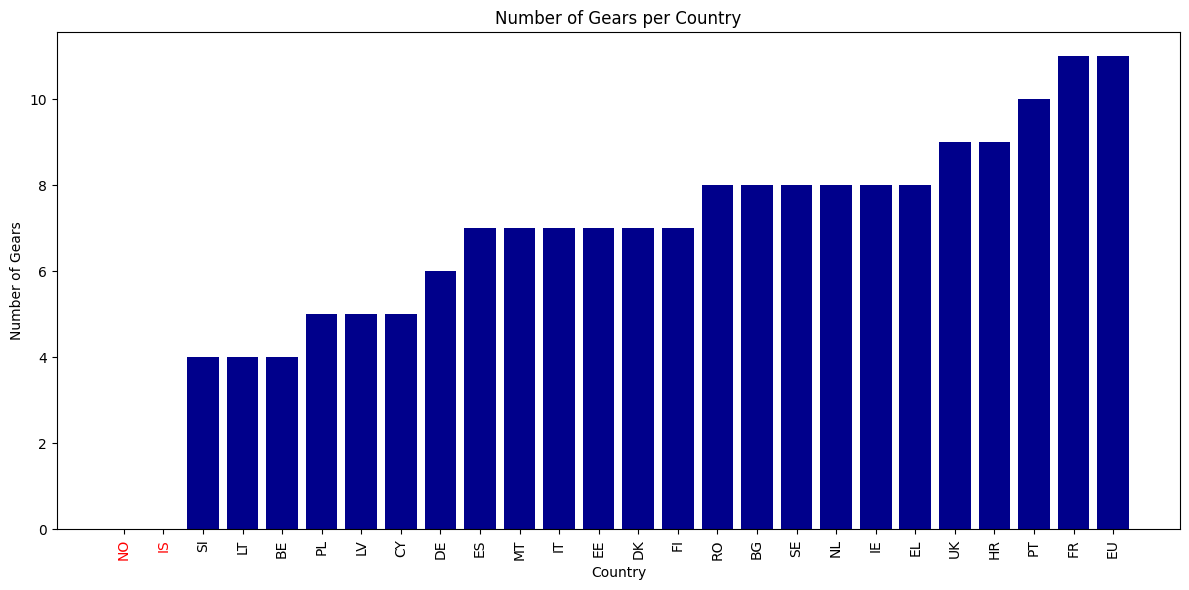

In [18]:
import matplotlib.pyplot as plt

# Base filter
df_filtered = df[
    (df["unit"] == "NR") &
    (df["eng_pow"] == "TOTAL") &
    (df["gear"].str.upper() != "TOTAL")
]

# All countries present in the dataset
all_countries = df[(df["unit"] == "NR") & (df["eng_pow"] == "TOTAL")]["geo"].unique()

# Count gears per country
gear_counts = (
    df_filtered.groupby("geo")["gear"]
    .nunique()
    .reindex(all_countries, fill_value=0)
    .sort_values()
)

# Plot
plt.figure(figsize=(12,6))
plt.bar(gear_counts.index, gear_counts.values, color="darkblue")
plt.xlabel("Country")
plt.ylabel("Number of Gears")
plt.title("Number of Gears per Country")

# Rotate axis labels
plt.xticks(rotation=90)

# Re-color tick labels for countries with 0 values
ax = plt.gca()
for tick, value in zip(ax.get_xticklabels(), gear_counts.values):
    if value == 0:
        tick.set_color("red")

plt.tight_layout()
plt.show()
